#  Preprocessing dataset

## Read dataset

In [ ]:
import os
from PIL import Image, ImageEnhance, ImageFilter
from PIL import Image, ImageChops
from io import BytesIO
import cv2
import numpy as np
import matplotlib.pyplot as plt

original_dataset = "C:\\Users\\PC\\WX\\dataset"  
preprocessed_dataset = "C:\\Users\\PC\\WX\\preprocessed_dataset" 

if os.path.exists(original_dataset):
    print("Dataset found")
else:
    print("Dataset not found.")

Dataset found


## Cleaning the Images 

- Reduce Noise
- Enhance Contrast

In [ ]:
# Function to clean blurry images
def clean_blurry_image(image_path, output_path):
    try:
        image = Image.open(image_path).convert("RGB") 

        # Enhance Contrast (Less aggressive)
        enhancer = ImageEnhance.Contrast(image)
        image = enhancer.enhance(1.2)

        # Reduce Noise (Weaker noise removal)
        image = image.filter(ImageFilter.MedianFilter(size=3))

        # Save the cleaned image
        image.save(output_path)

    except Exception as e:
        print(f"Error processing {image_path}: {e}")



In [3]:
dataset_path = "C:\\Users\\PC\\WX\\dataset"
cleaned_path = "C:\\Users\\PC\\WX\\cleaned_dataset"

# Ensure output directories exist
os.makedirs(cleaned_path, exist_ok=True)

# Apply cleaning to Train, Validation, and Test datasets
for split in ["train", "validation", "test"]:
    for label in ["real", "fake"]:
        input_folder = os.path.join(dataset_path, split, label)
        output_folder = os.path.join(cleaned_path, split, label)
        os.makedirs(output_folder, exist_ok=True)

        for filename in os.listdir(input_folder):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            clean_blurry_image(input_path, output_path)

print(f" Blurry images cleaned and saved in: {cleaned_path}")


 Blurry images cleaned and saved in: C:\Users\PC\WX\cleaned_dataset


## Result of Cleaning images 

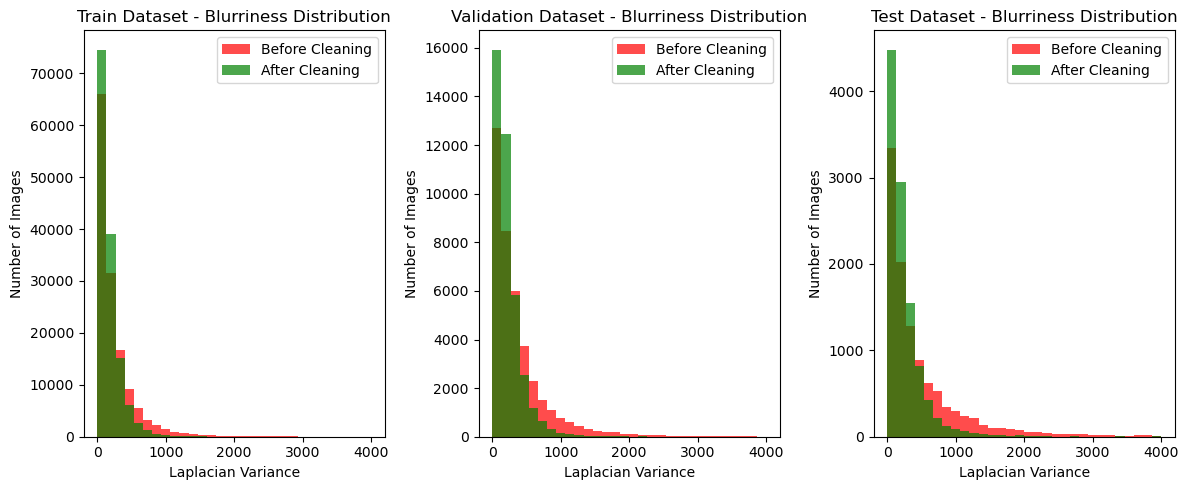

In [ ]:
dataset_path = "C:\\Users\\PC\\WX\\dataset"
cleaned_path = "C:\\Users\\PC\\WX\\cleaned_dataset"

# Storage for blurriness scores
blurriness_scores_before = {"train": [], "validation": [], "test": []}
blurriness_scores_after = {"train": [], "validation": [], "test": []}

# Loop over all dataset splits
for split in ["train", "validation", "test"]:
    for label in ["real", "fake"]:
        input_folder = os.path.join(dataset_path, split, label)
        cleaned_folder = os.path.join(cleaned_path, split, label)

        # Skip if folders don't exist
        if not os.path.exists(input_folder) or not os.path.exists(cleaned_folder):
            print(f"Skipping missing folder: {input_folder} or {cleaned_folder}")
            continue  

        for filename in os.listdir(input_folder):
            input_path = os.path.join(input_folder, filename)
            cleaned_image_path = os.path.join(cleaned_folder, filename)

            # Read images in grayscale
            img_before = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
            img_after = cv2.imread(cleaned_image_path, cv2.IMREAD_GRAYSCALE)

            # Ensure both images are loaded correctly
            if img_before is None or img_after is None:
                print(f"Skipping invalid image: {filename}")
                continue

            # Compute Laplacian Variance (Blurriness Score)
            blur_before = cv2.Laplacian(img_before, cv2.CV_64F).var()
            blur_after = cv2.Laplacian(img_after, cv2.CV_64F).var()

            # Store results
            blurriness_scores_before[split].append(blur_before)
            blurriness_scores_after[split].append(blur_after)

# Convert lists to numpy arrays (Handle empty cases safely)
for split in blurriness_scores_before:
    blurriness_scores_before[split] = np.array(blurriness_scores_before[split]) if blurriness_scores_before[split] else np.array([0])
    blurriness_scores_after[split] = np.array(blurriness_scores_after[split]) if blurriness_scores_after[split] else np.array([0])

# Automatically determine range (Handling empty lists safely)
range_max = max(
    np.max(blurriness_scores_before["train"], initial=0),
    np.max(blurriness_scores_after["train"], initial=0),
    np.max(blurriness_scores_before["validation"], initial=0),
    np.max(blurriness_scores_after["validation"], initial=0),
    np.max(blurriness_scores_before["test"], initial=0),
    np.max(blurriness_scores_after["test"], initial=0),
)

bins_range = (0, min(range_max, 4000))  # Limit to 4000 if values exceed

# Plot Before vs After Cleaning (For Each Dataset)
plt.figure(figsize=(12, 5))
for i, split in enumerate(["train", "validation", "test"]):
    plt.subplot(1, 3, i + 1)
    plt.hist(blurriness_scores_before[split], bins=30, alpha=0.7, color="red", label="Before Cleaning", range=bins_range)
    plt.hist(blurriness_scores_after[split], bins=30, alpha=0.7, color="green", label="After Cleaning", range=bins_range)
    plt.title(f"{split.capitalize()} Dataset - Blurriness Distribution")
    plt.xlabel("Laplacian Variance")
    plt.ylabel("Number of Images")
    plt.legend()

plt.tight_layout()
plt.show()


# 1.4 Resize image and Apply ELA

- Since I am using ResNeXt-50 pretrained model, then have to resize the image to 224x224

In [6]:
preprocessed_dataset = "C:\\Users\\PC\\WX\\preprocessed_dataset" 
cleaned_train_path = "C:\\Users\\PC\\WX\\cleaned_dataset" 

# Ensure output directory exists
os.makedirs(preprocessed_dataset, exist_ok=True)

# Function to Apply ELA
def apply_ela(image, quality=90):
    """Apply Error Level Analysis (ELA) to highlight compression artifacts."""
    buffer = BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    buffer.seek(0)
    compressed = Image.open(buffer)

    # Compute ELA (Difference between original & compressed images)
    ela_image = ImageChops.difference(image, compressed)

    # Normalize ELA image
    extrema = ela_image.getextrema()
    max_diff = max([e[1] for e in extrema])
    scale = 255.0 / max_diff if max_diff != 0 else 1
    ela_image = ela_image.point(lambda p: p * scale)

    return ela_image


In [7]:
# Function to Resize and Apply ELA
def process_images(input_folder, output_folder, size=(224, 224)):
    """Resize and apply ELA to all images in a folder."""
    os.makedirs(output_folder, exist_ok=True)  

    if not os.path.exists(input_folder): 
        print(f" Skipping missing folder: {input_folder}")
        return

    for filename in os.listdir(input_folder):
        img_path = os.path.join(input_folder, filename)
        img = Image.open(img_path).convert("RGB")  

        # Resize to 224x224
        img = img.resize(size)

        # Apply ELA
        ela_img = apply_ela(img)

        # Save final preprocessed image
        ela_img.save(os.path.join(output_folder, filename))

    print(f" Processed {input_folder} → {output_folder}")


In [8]:
# Process Validation & Test Data (Use original dataset)
for split in ["train","validation", "test"]:
    for label in ["real", "fake"]:
        input_folder = os.path.join(original_dataset, split, label)  
        output_folder = os.path.join(preprocessed_dataset, split, label) 
        process_images(input_folder, output_folder)

print(f"\n All images resized, ELA applied, and saved in: {preprocessed_dataset}")

 Processed C:\Users\PC\WX\dataset\train\real → C:\Users\PC\WX\preprocessed_dataset\train\real
 Processed C:\Users\PC\WX\dataset\train\fake → C:\Users\PC\WX\preprocessed_dataset\train\fake
 Processed C:\Users\PC\WX\dataset\validation\real → C:\Users\PC\WX\preprocessed_dataset\validation\real
 Processed C:\Users\PC\WX\dataset\validation\fake → C:\Users\PC\WX\preprocessed_dataset\validation\fake
 Processed C:\Users\PC\WX\dataset\test\real → C:\Users\PC\WX\preprocessed_dataset\test\real
 Processed C:\Users\PC\WX\dataset\test\fake → C:\Users\PC\WX\preprocessed_dataset\test\fake

 All images resized, ELA applied, and saved in: C:\Users\PC\WX\preprocessed_dataset
